This notebook contains the full implementation and report for Task 2 (customer churn prediction).

The task specification and sample schema are provided in the appendix at the end of this notebook.

# Task 2 Report: Churn Prediction

## Task objective
Predict customer churn probability (`Exited`) for `test.csv` using `train.csv` and report the modeling workflow and outcomes.

## 1) Training data visualization strategy
The raw training features are mixed-type tabular data (numeric + categorical), so the visualization pipeline first converts them into a model-ready numeric representation and then projects to 2D:

- Sample `12,000` rows from training data using stratified sampling on `Exited` to keep class balance while making visualization computationally practical.
- Drop non-informative identifier columns (`id`, `CustomerId`, `Surname`).
- Preprocess features with a `ColumnTransformer`:
  - Standardize continuous numeric features (`CreditScore`, `Age`, `Balance`, `EstimatedSalary`).
  - One-hot encode categorical features (e.g., `Geography`, `Gender`).
  - Keep binary/count-like numeric columns as passthrough.
- Project high-dimensional vectors into 2D using both:
  - `UMAP` (better local/global structure trade-off),
  - `t-SNE` (cluster-focused local neighborhood view).
- Color points by `Exited` to visually inspect separability between churn and non-churn groups.

Using both UMAP and t-SNE provides complementary structure checks and helps confirm that class boundaries are non-linear, which motivates a non-linear model.

In [1]:
# Step 1: Visualize high-dimensional training data in 2D with t-SNE

import importlib.util
import subprocess
import sys
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import umap.umap_ as umap
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.manifold import TSNE
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler



In [2]:
def load_train_data() -> pd.DataFrame:
    return pd.read_csv(Path("train.csv"))


def sample_for_visualization(df: pd.DataFrame, sample_n: int = 12000, random_state: int = 42) -> pd.DataFrame:
    if len(df) <= sample_n:
        return df.copy()

    _, sample_idx = train_test_split(
        df.index,
        test_size=sample_n,
        stratify=df["Exited"],
        random_state=random_state,
    )
    return df.loc[sample_idx].copy()


def build_preprocessor(X: pd.DataFrame):
    # Standardize continuous numeric features used in distance-based visualization.
    continuous_cols_to_scale = ["CreditScore", "Age", "Balance", "EstimatedSalary"]
    scale_cols = [col for col in continuous_cols_to_scale if col in X.columns]

    categorical_cols = X.select_dtypes(include=["object", "category", "string"]).columns.tolist()

    # Keep binary/count features as-is (no standardization).
    passthrough_cols = [
        col
        for col in X.columns
        if col not in categorical_cols and col not in scale_cols
    ]

    transformers = []
    if scale_cols:
        transformers.append(("num_scaled", StandardScaler(), scale_cols))
    if passthrough_cols:
        transformers.append(("num_passthrough", "passthrough", passthrough_cols))
    if categorical_cols:
        transformers.append(
            ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols)
        )

    return ColumnTransformer(transformers=transformers)


def prepare_data_for_visualization(df: pd.DataFrame):
    y = df["Exited"].astype(int)
    X = df.drop(columns=["Exited", "id", "CustomerId", "Surname"], errors="ignore")

    preprocessor = build_preprocessor(X)
    X_processed = preprocessor.fit_transform(X)
    return X_processed, y


def project_with_umap(X_processed, n_components: int = 2, random_state: int = 42):
    reducer = umap.UMAP(
        n_components=n_components,
        n_neighbors=30,
        min_dist=0.1,
        metric="euclidean",
        random_state=random_state,
    )
    return reducer.fit_transform(X_processed)


def project_with_tsne(X_processed, n_components: int = 2, random_state: int = 42):
    reducer = TSNE(
        n_components=n_components,
        perplexity=30,
        learning_rate="auto",
        init="pca",
        random_state=random_state,
    )
    return reducer.fit_transform(X_processed)


def plot_embedding(embedding_2d, y, title: str, x_label: str, y_label: str) -> None:
    plt.figure(figsize=(10, 7))
    scatter = plt.scatter(
        embedding_2d[:, 0],
        embedding_2d[:, 1],
        c=y,
        s=8,
        alpha=0.7,
        cmap="coolwarm",
    )
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.title(title)
    legend = plt.legend(*scatter.legend_elements(), title="Exited")
    plt.gca().add_artist(legend)
    plt.tight_layout()
    plt.show()


def plot_embedding_3d(embedding_3d, y, title: str) -> None:
    fig = plt.figure(figsize=(11, 8))
    ax = fig.add_subplot(111, projection="3d")
    scatter = ax.scatter(
        embedding_3d[:, 0],
        embedding_3d[:, 1],
        embedding_3d[:, 2],
        c=y,
        s=8,
        alpha=0.7,
        cmap="coolwarm",
    )
    ax.set_xlabel("Dim-1")
    ax.set_ylabel("Dim-2")
    ax.set_zlabel("Dim-3")
    ax.set_title(title)
    legend = ax.legend(*scatter.legend_elements(), title="Exited")
    ax.add_artist(legend)
    plt.tight_layout()
    plt.show()

train_df = load_train_data()
viz_df = sample_for_visualization(train_df, sample_n=12000)
X_processed, y = prepare_data_for_visualization(viz_df)


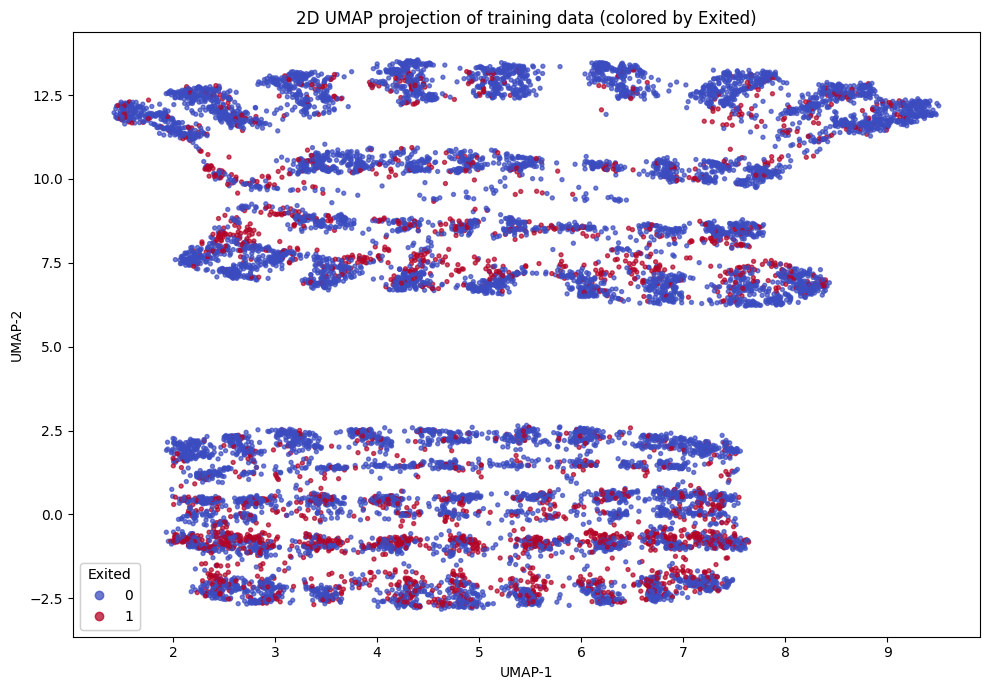

In [3]:
umap_embedding = project_with_umap(X_processed)
plot_embedding(
    umap_embedding,
    y,
    title="2D UMAP projection of training data (colored by Exited)",
    x_label="UMAP-1",
    y_label="UMAP-2",
)

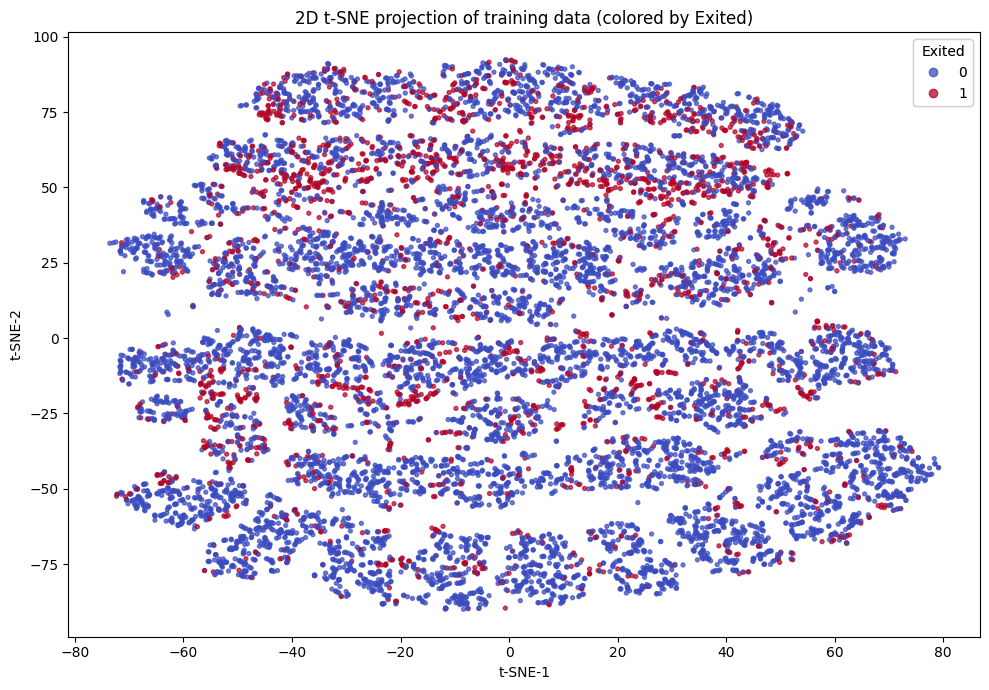

In [4]:
tsne_embedding = project_with_tsne(X_processed)
plot_embedding(
    tsne_embedding,
    y,
    title="2D t-SNE projection of training data (colored by Exited)",
    x_label="t-SNE-1",
    y_label="t-SNE-2",
)

## 2) Splitting strategy

The training set is split into train/validation with:

- `train_test_split(test_size=0.2, stratify=y, random_state=42)`

Why this split:

- **Stratified**: preserves churn ratio in both train and validation sets (important for imbalanced binary targets).
- **80/20 holdout**: enough data for training while keeping a reliable validation set.
- **Fixed random seed**: reproducible results.

Leakage is avoided by fitting preprocessing and model only on `X_train`, then applying the fitted pipeline to `X_val`.

In [5]:
# Split data into training and validation sets
# Use stratification so the Exited class ratio stays consistent.
model_df = load_train_data()

y_full = model_df["Exited"].astype(int)
X_full = model_df.drop(columns=["Exited", "id", "CustomerId", "Surname"], errors="ignore")

X_train, X_val, y_train, y_val = train_test_split(
    X_full,
    y_full,
    test_size=0.2,
    stratify=y_full,
    random_state=42,
)

print(f"Train shape: {X_train.shape}, Validation shape: {X_val.shape}")
print(f"Exited rate (train): {y_train.mean():.4f}")
print(f"Exited rate (validation): {y_val.mean():.4f}")

Train shape: (132027, 10), Validation shape: (33007, 10)
Exited rate (train): 0.2116
Exited rate (validation): 0.2116


## 3) Why `HistGradientBoostingClassifier`

`HistGradientBoostingClassifier` is used because it is a strong default for large tabular datasets:

- Captures non-linear relationships and feature interactions better than linear baselines.
- Efficient histogram-based training scales well to this dataset size.
- Robust performance with moderate hyperparameter tuning.
- Works well in a pipeline after one-hot encoding mixed categorical/numeric inputs.

Compared with deep neural networks, this model is usually more sample-efficient and easier to tune on structured tabular data.

In [6]:
# Train model

# Reuse the same preprocessing strategy used earlier.
train_preprocessor = build_preprocessor(X_train)

clf = Pipeline(
    steps=[
        ("preprocess", train_preprocessor),
        (
            "model",
            HistGradientBoostingClassifier(
                learning_rate=0.05,
                max_iter=300,
                min_samples_leaf=40,
                random_state=42,
            ),
        ),
    ]
)

clf.fit(X_train, y_train)
print("Model training completed.")


Model training completed.


Validation metrics
------------------------------------------------------------
ROC-AUC:    0.8899
PR-AUC:     0.7295
F1 @0.50:   0.6353
Precision @0.50: 0.7480
Recall @0.50:    0.5521
Best threshold by F1: 0.3257
F1 @best:   0.6669
Precision @best: 0.6493
Recall @best:    0.6854
Confusion Matrix @best threshold:
[[23438  2585]
 [ 2197  4787]]


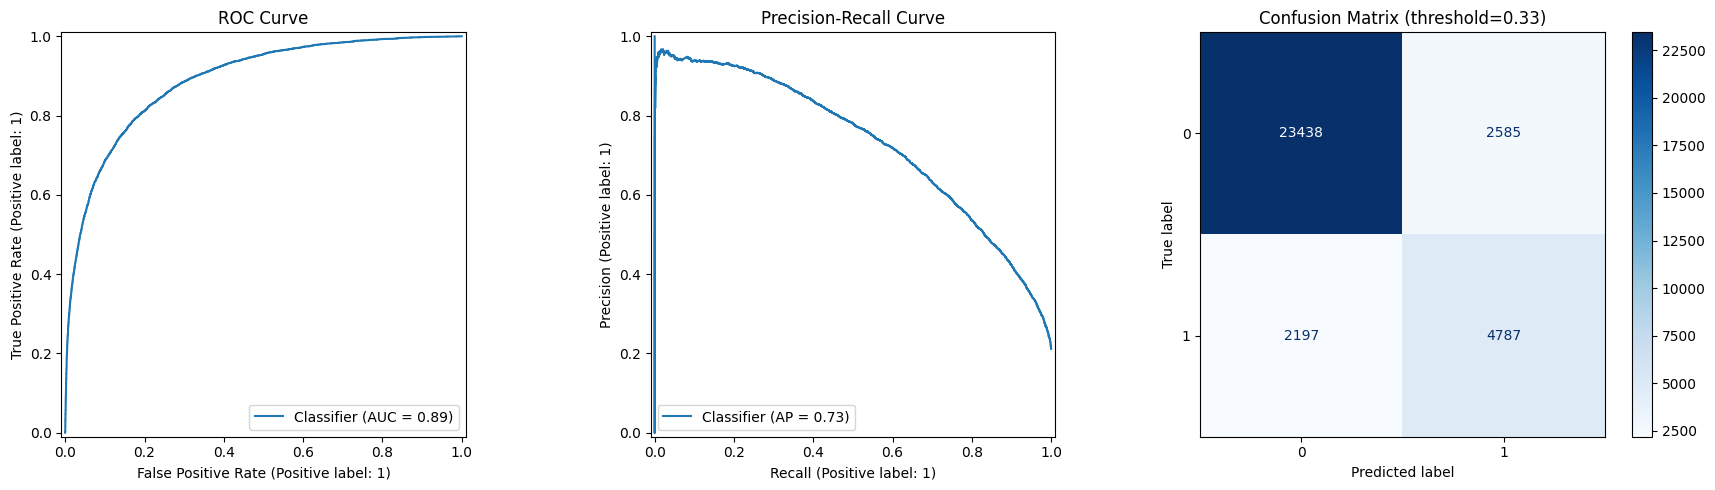

In [7]:
# Validate model on validation data

val_proba = clf.predict_proba(X_val)[:, 1]

# Default threshold metrics
default_threshold = 0.5
val_pred_default = (val_proba >= default_threshold).astype(int)

f1_default = f1_score(y_val, val_pred_default)
precision_default = precision_score(y_val, val_pred_default)
recall_default = recall_score(y_val, val_pred_default)
roc_auc = roc_auc_score(y_val, val_proba)
pr_auc = average_precision_score(y_val, val_proba)

# Threshold tuning for best F1 on validation
precisions, recalls, thresholds = precision_recall_curve(y_val, val_proba)
f1_curve = (2 * precisions * recalls) / (precisions + recalls + 1e-12)
best_idx = np.argmax(f1_curve[:-1])  # exclude final PR point with no threshold
best_threshold = thresholds[best_idx]

val_pred_best = (val_proba >= best_threshold).astype(int)
f1_best = f1_score(y_val, val_pred_best)
precision_best = precision_score(y_val, val_pred_best)
recall_best = recall_score(y_val, val_pred_best)
cm_best = confusion_matrix(y_val, val_pred_best)

print("Validation metrics")
print("-" * 60)
print(f"ROC-AUC:    {roc_auc:.4f}")
print(f"PR-AUC:     {pr_auc:.4f}")
print(f"F1 @0.50:   {f1_default:.4f}")
print(f"Precision @0.50: {precision_default:.4f}")
print(f"Recall @0.50:    {recall_default:.4f}")
print(f"Best threshold by F1: {best_threshold:.4f}")
print(f"F1 @best:   {f1_best:.4f}")
print(f"Precision @best: {precision_best:.4f}")
print(f"Recall @best:    {recall_best:.4f}")
print("Confusion Matrix @best threshold:")
print(cm_best)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

RocCurveDisplay.from_predictions(y_val, val_proba, ax=axes[0])
axes[0].set_title("ROC Curve")

PrecisionRecallDisplay.from_predictions(y_val, val_proba, ax=axes[1])
axes[1].set_title("Precision-Recall Curve")

ConfusionMatrixDisplay.from_predictions(y_val, val_pred_best, ax=axes[2], cmap="Blues")
axes[2].set_title(f"Confusion Matrix (threshold={best_threshold:.2f})")

plt.tight_layout()
plt.show()


## 4) Validation result

Validation metrics from one notebook run:

- `ROC-AUC`: **0.8899**
- `PR-AUC`: **0.7295**
- `F1 @ threshold 0.50`: **0.6353**
- `Precision @ 0.50`: **0.7480**
- `Recall @ 0.50`: **0.5521**

Threshold tuning on validation (maximize F1):

- Best threshold: **0.3257**
- `F1 @ best threshold`: **0.6669**
- `Precision @ best`: **0.6493**
- `Recall @ best`: **0.6854**

Confusion matrix at best threshold (`[[TN, FP], [FN, TP]]`):

- `[[23438, 2585], [2197, 4787]]`

Interpretation:

- The model has strong ranking ability (`ROC-AUC` and `PR-AUC`).
- Lowering threshold from `0.50` to `0.3257` improves F1 by increasing recall substantially, which is often desirable for churn detection.

Saved predictions to: /home/lai/AID-SDS/task2/test_predicted_probabilities.csv
       id    Exited
0  165034  0.023949
1  165035  0.814155
2  165036  0.030095
3  165037  0.238566
4  165038  0.398909


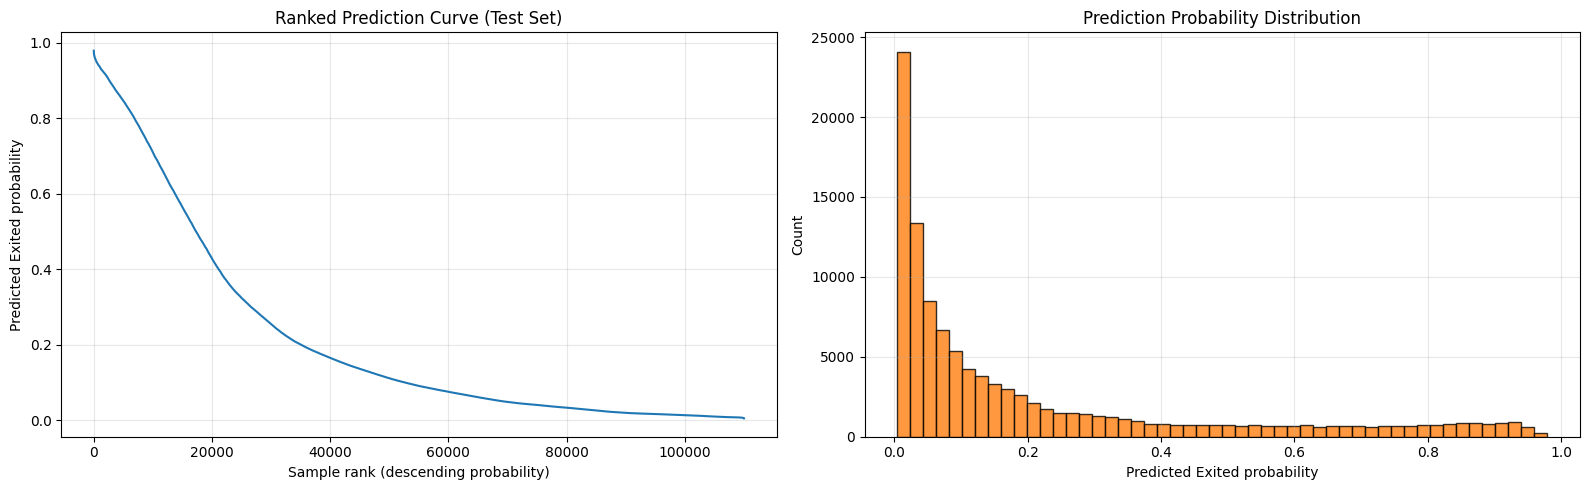

In [8]:
# Run inference on test.csv and export Exited probabilities
# Requires the trained `clf` pipeline from the training cell.
test_df = pd.read_csv(Path("test.csv"))

test_ids = (
    test_df["id"].copy()
    if "id" in test_df.columns
    else pd.Series(np.arange(len(test_df)), name="id")
)

X_test = test_df.drop(columns=["id", "CustomerId", "Surname"], errors="ignore")
test_proba = clf.predict_proba(X_test)[:, 1]

submission = pd.DataFrame({
    "id": test_ids,
    "Exited": test_proba,
})

output_path = Path("test_predicted_probabilities.csv")
submission.to_csv(output_path, index=False)

print(f"Saved predictions to: {output_path.resolve()}")
print(submission.head())

# Plot prediction curves for test probabilities
sorted_proba = np.sort(test_proba)[::-1]
ranks = np.arange(1, len(sorted_proba) + 1)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(ranks, sorted_proba, color="tab:blue", linewidth=1.5)
axes[0].set_title("Ranked Prediction Curve (Test Set)")
axes[0].set_xlabel("Sample rank (descending probability)")
axes[0].set_ylabel("Predicted Exited probability")
axes[0].grid(alpha=0.3)

axes[1].hist(test_proba, bins=50, color="tab:orange", edgecolor="black", alpha=0.8)
axes[1].set_title("Prediction Probability Distribution")
axes[1].set_xlabel("Predicted Exited probability")
axes[1].set_ylabel("Count")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 5) Testing result

Inference on `test.csv` is exported to:

- `task2/test_predicted_probabilities.csv`

Output format:

- Columns: `id`, `Exited`
- `Exited` is predicted churn probability from `clf.predict_proba(X_test)[:, 1]`
- Rows predicted: **110,023** (plus header in CSV file)

Probability distribution summary from one run:

- Min: `0.0045`
- Max: `0.9794`
- Mean: `0.2109`
- Std: `0.2592`
- Quantiles: `q10=0.0134`, `q25=0.0290`, `q50=0.0904`, `q75=0.2876`, `q90=0.6802`

The ranked prediction curve and histogram indicate most samples have low churn probability, with a smaller high-risk tail, which is consistent with churn imbalance patterns.

## Appendix: Task Specification and Data Format

### Datasets
- **Training dataset:** `train.csv` (target column: `Exited`)
- **Testing dataset:** `test.csv`

### Sample training record
```text
id: 0
CustomerId: 15674932
Surname: Okwudilichukwu
CreditScore: 668
Geography: France
Gender: Male
Age: 33.0
Tenure: 3
Balance: 0.0
NumOfProducts: 2
HasCrCard: 1.0
IsActiveMember: 0.0
EstimatedSalary: 181449.97
Exited: 0
```

### Required tasks
1. Visualize the training data by mapping high-dimensional features into a 2D plane.
2. Split the training dataset into training and validation sets.
3. Train a model on the training dataset.
4. Validate the model on the validation dataset.
5. Output a CSV containing predicted `Exited` probabilities for the testing dataset.